# Частотный взгляд на нейросети: гармонический анализ, F -принцип и динамика обучения 
## Практическая часть
### Цели: 
- Проверить на синтетических примерах наличие F-принципа 
- Установить практически насколько сильно признаки Фурье ускоряют обучение высоких частот
- Исследовать влияние ширины сети и шага обучения на спектральные кривые 

### F-принцип на синтетических примерах

#### Установка необходимых библиотек:

In [10]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Целевые функции

In [11]:
# 1D: сумма синусов с заданными частотами
def generate_1d_function(n_samples=1024, freqs=[1, 3, 5], amplitudes=None):
    x = np.linspace(0, 2*np.pi, n_samples)
    
    if amplitudes is None:
        amplitudes = np.ones(len(freqs))
    
    y = np.zeros_like(x)
    for a, f in zip(amplitudes, freqs):
        y += a * np.sin(f * x)
    
    return x, y

# Альтернатива: сглаженная ступень (высокие частоты)
def smooth_step(x, sharpness=10):
    return np.tanh(sharpness * (x - np.pi))

# 2D: сумма гармоник
def generate_2d_function(n=64, freqs=[(1,1), (2,3)]):
    x = np.linspace(0, 2*np.pi, n)
    y = np.linspace(0, 2*np.pi, n)
    X, Y = np.meshgrid(x, y)
    
    Z = np.zeros_like(X)
    for fx, fy in freqs:
        Z += np.sin(fx * X + fy * Y)
    
    return X, Y, Z

#### MLP сеть

In [12]:
class MLP(nn.Module):
    def __init__(self, in_dim=1, hidden=128, depth=3, activation='tanh'):
        super().__init__()
        
        act = nn.Tanh() if activation == 'tanh' else nn.ReLU()
        
        layers = [nn.Linear(in_dim, hidden), act]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), act]
        layers += [nn.Linear(hidden, 1)]
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

#### Фурье-коэффициенты

In [13]:
# 1D FFT
def compute_fft_1d(signal):
    fft = np.fft.fft(signal)
    return fft

# 2D FFT
def compute_fft_2d(signal):
    fft = np.fft.fft2(signal)
    return fft

#### Обучение и измерение спектра

In [14]:
def train_with_spectral_tracking(x, y, epochs=500, lr=1e-3, activation='tanh'):
    
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)
    
    model = MLP(activation=activation).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    # истинный спектр
    true_fft = compute_fft_1d(y)
    
    spectral_errors = []
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        pred = model(x_tensor)
        loss = loss_fn(pred, y_tensor)
        loss.backward()
        optimizer.step()
        
        # анализ спектра
        with torch.no_grad():
            pred_np = pred.cpu().numpy().flatten()
            pred_fft = compute_fft_1d(pred_np)
            
            # ошибка по модам
            Ek = np.abs(true_fft - pred_fft) ** 2
            spectral_errors.append(Ek)
        
        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Loss {loss.item():.6f}")
    
    return model, np.array(spectral_errors), true_fft

#### Визуализация

##### Ошибки по частотам

In [15]:
def plot_spectral_dynamics(spectral_errors, max_k=20):
    spectral_errors = np.array(spectral_errors)
    
    for k in range(max_k):
        plt.plot(spectral_errors[:, k], label=f"k={k}")
    
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("E_k(t)")
    plt.title("Spectral Error Dynamics (F-principle)")
    plt.legend()
    plt.show()

##### Итог обучения

In [16]:
def plot_fit(x, y, model):
    with torch.no_grad():
        pred = model(torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device))
        pred = pred.cpu().numpy()
    
    plt.plot(x, y, label="True")
    plt.plot(x, pred, '--', label="MLP")
    plt.legend()
    plt.show()

#### Запуск эксперименнта

Epoch 0, Loss 0.702119
Epoch 50, Loss 0.156265
Epoch 100, Loss 0.143419
Epoch 150, Loss 0.122818
Epoch 200, Loss 0.073049
Epoch 250, Loss 0.056548
Epoch 300, Loss 0.044328
Epoch 350, Loss 0.041741
Epoch 400, Loss 0.039056
Epoch 450, Loss 0.037524


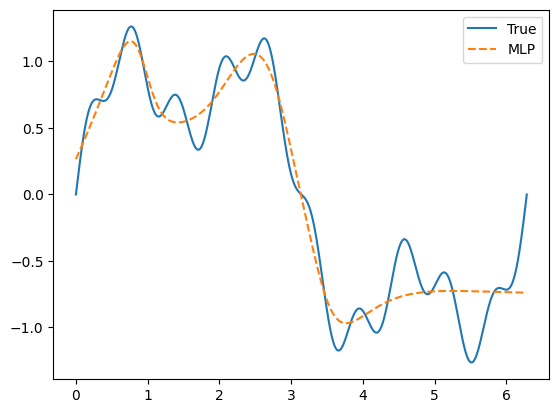

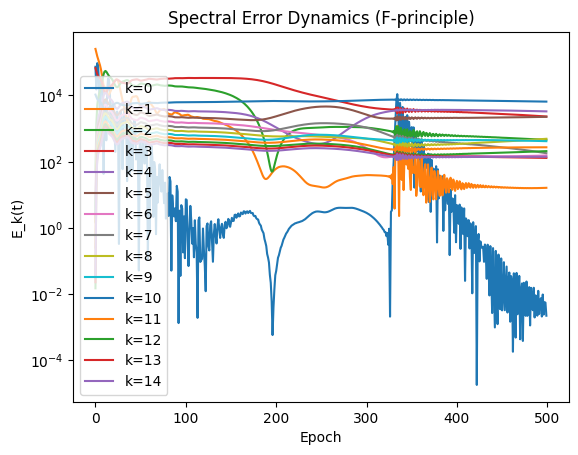

In [17]:
# низкие + высокие частоты
x, y = generate_1d_function(
    freqs=[1, 3, 10],
    amplitudes=[1.0, 0.5, 0.2]
)

model, spectral_errors, true_fft = train_with_spectral_tracking(
    x, y, epochs=500, activation='tanh'
)

plot_fit(x, y, model)
plot_spectral_dynamics(spectral_errors, max_k=15)